# PHIL-TEXT — Faz 4.1 & 4.2: Baseline Model + Model Geliştirme

**Amaç:** TF-IDF üzerinde 5 farklı sınıflandırıcıyı dene, cross-validate et, karşılaştır ve en iyi modeli kaydet.

### Adımlar
1. Veriyi yükle (splits.npz)
2. Faz 4.1 — Baseline: Logistic Regression
3. Faz 4.2 — Model Karşılaştırması: SVM / RF / GBT / LR
4. Cross-Validation analizi
5. Confusion Matrix
6. Model Karşılaştırma Grafikleri
7. En iyi modeli kaydet

## 1. Kurulum & Veri Yükleme

In [1]:
import sys, os, json, time, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_class_weight

from src.models.evaluate import evaluate_classification, plot_confusion_matrix, compare_models

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

# Splits yükle
data = np.load('../data/processed/splits.npz', allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']

with open('../data/processed/label_mappings.json', encoding='utf-8') as f:
    mappings = json.load(f)
    
id2label = {v: k for k, v in mappings['philosopher'].items()}
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Siniflar ({len(id2label)}): {list(id2label.values())}')

Train: 2,898 | Val: 621 | Test: 621
Siniflar (10): ['aristoteles', 'descartes', 'hume', 'kant', 'locke', 'marcus_aurelius', 'nietzsche', 'platon', 'schopenhauer', 'spinoza']


In [2]:
# Class weights (imbalanced dataset için)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print('Class weights:')
for cls_id, w in sorted(class_weight_dict.items()):
    print(f'  {id2label[cls_id]:<20}: {w:.3f}')

Class weights:
  aristoteles         : 0.751
  descartes           : 6.300
  hume                : 0.703
  kant                : 0.716
  locke               : 1.178
  marcus_aurelius     : 2.659
  nietzsche           : 0.835
  platon              : 0.558
  schopenhauer        : 0.999
  spinoza             : 2.100


## 2. Faz 4.1 — Baseline: Logistic Regression

In [3]:
print('=== BASELINE: TF-IDF + Logistic Regression ===')
t0 = time.time()

baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), sublinear_tf=True, stop_words='english')),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42, n_jobs=-1)),
])

baseline_pipeline.fit(X_train, y_train)
y_pred_val = baseline_pipeline.predict(X_val)

baseline_metrics = evaluate_classification(y_val, y_pred_val, id2label)
print(f'\nEgitim suresi: {time.time() - t0:.1f}s')
print(f'Val Accuracy : {baseline_metrics["accuracy"]:.4f}')
print(f'Val F1 (W)   : {baseline_metrics["f1_weighted"]:.4f}')
print(f'Val F1 (M)   : {baseline_metrics["f1_macro"]:.4f}')
print()
print(baseline_metrics['report'])

=== BASELINE: TF-IDF + Logistic Regression ===


2026-02-25 15:28:26.410 | INFO     | src.models.evaluate:evaluate_classification:17 - Accuracy: 0.9968 | F1: 0.9968



Egitim suresi: 2.5s
Val Accuracy : 0.9968
Val F1 (W)   : 0.9968
Val F1 (M)   : 0.9975

                 precision    recall  f1-score   support

    aristoteles       1.00      0.99      0.99        83
      descartes       1.00      1.00      1.00        10
           hume       1.00      1.00      1.00        88
           kant       1.00      1.00      1.00        87
          locke       1.00      1.00      1.00        53
marcus_aurelius       1.00      1.00      1.00        24
      nietzsche       0.99      1.00      0.99        74
         platon       0.99      1.00      1.00       111
   schopenhauer       1.00      0.98      0.99        62
        spinoza       1.00      1.00      1.00        29

       accuracy                           1.00       621
      macro avg       1.00      1.00      1.00       621
   weighted avg       1.00      1.00      1.00       621



## 3. Faz 4.2 — Model Karşılaştırması

In [4]:
MODELS = {
    'LogisticReg':  LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42, n_jobs=-1),
    'LinearSVC':    LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42),
    'ComplementNB': ComplementNB(alpha=0.1),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=25, class_weight='balanced',
                                           random_state=42, n_jobs=-1),
    'GradientBoost': GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                                random_state=42),
}

TFIDF = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), sublinear_tf=True, stop_words='english')
X_train_tfidf = TFIDF.fit_transform(X_train)
X_val_tfidf   = TFIDF.transform(X_val)
X_test_tfidf  = TFIDF.transform(X_test)

results = {}
trained_models = {}

print(f'{'Model':<20} {'Acc':>8} {'F1-W':>8} {'F1-M':>8} {'Süre':>8}')
print('-' * 55)

for name, clf in MODELS.items():
    t0 = time.time()
    
    # ComplementNB sparse input ister (negatif değer yok)
    if name == 'ComplementNB':
        from sklearn.preprocessing import MaxAbsScaler
        scaler = MaxAbsScaler()
        Xtr = scaler.fit_transform(X_train_tfidf)
        Xvl = scaler.transform(X_val_tfidf)
    else:
        Xtr, Xvl = X_train_tfidf, X_val_tfidf
    
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xvl)
    elapsed = time.time() - t0
    
    acc  = accuracy_score(y_val, y_pred)
    f1w  = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    f1m  = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    results[name] = {'accuracy': acc, 'f1_weighted': f1w, 'f1_macro': f1m,
                     'y_pred': y_pred, 'train_time': elapsed}
    trained_models[name] = clf
    print(f'{name:<20} {acc:>8.4f} {f1w:>8.4f} {f1m:>8.4f} {elapsed:>7.1f}s')

Model                     Acc     F1-W     F1-M     Süre
-------------------------------------------------------


LogisticReg            0.9968   0.9968   0.9975     0.4s
LinearSVC              1.0000   1.0000   1.0000     0.1s
ComplementNB           0.9823   0.9793   0.9371     0.0s


RandomForest           0.9469   0.9450   0.9185     0.6s


GradientBoost          0.9452   0.9448   0.9140   112.5s


## 4. Cross-Validation Analizi

In [5]:
# Hız için sadece ilk 3 modele CV uygula
cv_results = {}
cv_models  = ['LogisticReg', 'LinearSVC', 'ComplementNB']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== 5-Fold Cross-Validation (F1 Weighted) ===')
for name in cv_models:
    clf = MODELS[name]
    t0  = time.time()
    scores = cross_val_score(clf, X_train_tfidf, y_train,
                              cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<20}: {scores.mean():.4f} ± {scores.std():.4f}  [{time.time()-t0:.0f}s]')

=== 5-Fold Cross-Validation (F1 Weighted) ===


LogisticReg         : 0.9934 ± 0.0033  [7s]


LinearSVC           : 0.9986 ± 0.0007  [4s]


ComplementNB        : 0.9713 ± 0.0038  [4s]


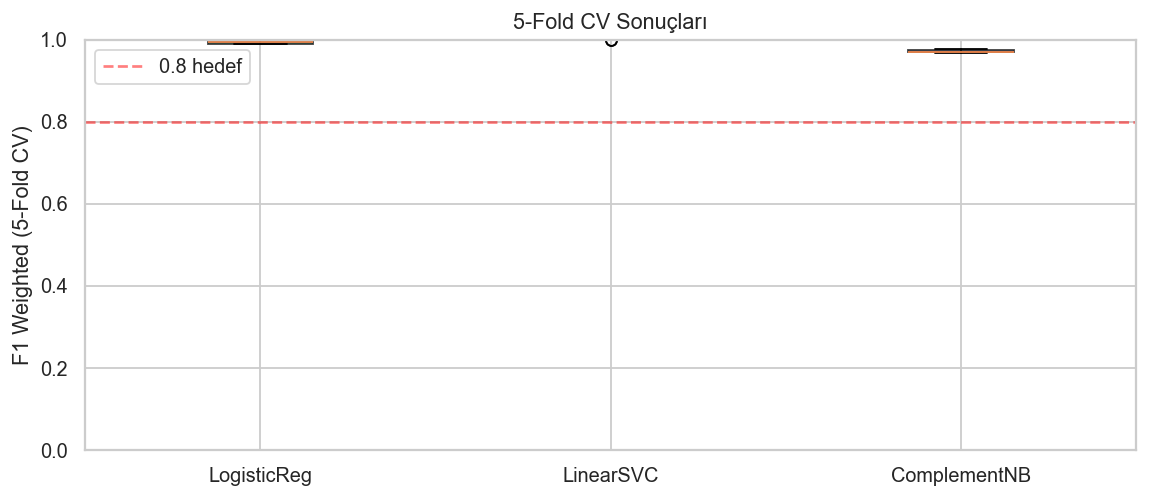

In [6]:
# CV skor kutu grafikleri
fig, ax = plt.subplots(figsize=(9, 4))
cv_data  = [cv_results[m] for m in cv_models]
bp = ax.boxplot(cv_data, vert=True, patch_artist=True, notch=False, labels=cv_models)
colors = sns.color_palette('Set2', len(cv_models))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_ylabel('F1 Weighted (5-Fold CV)')
ax.set_title('5-Fold CV Sonuçları')
ax.set_ylim(0, 1)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 hedef')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/model_cv_boxplot.png', bbox_inches='tight')
plt.show()

## 5. Confusion Matrix — En İyi Model

En iyi model: LinearSVC
Val Accuracy : 1.0000
Val F1 (W)   : 1.0000


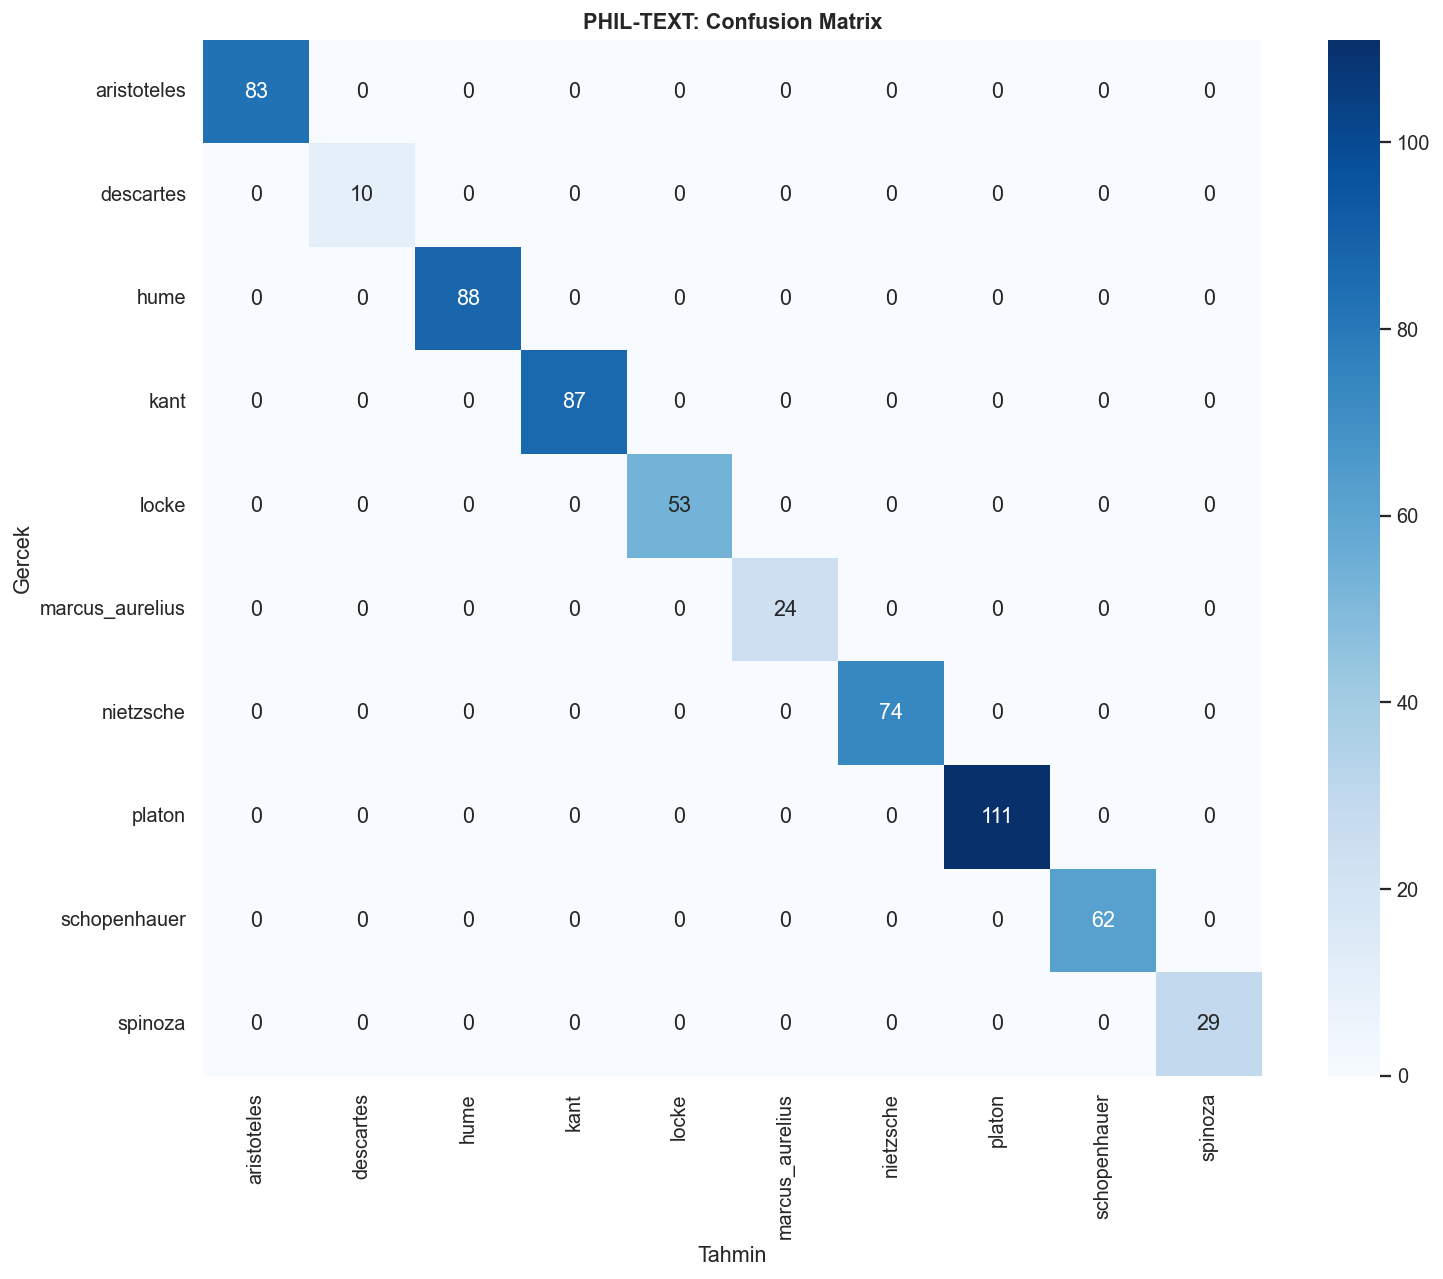

In [7]:
# En iyi model (f1_weighted'a göre)
best_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_pred = results[best_name]['y_pred']

print(f'En iyi model: {best_name}')
print(f'Val Accuracy : {results[best_name]["accuracy"]:.4f}')
print(f'Val F1 (W)   : {results[best_name]["f1_weighted"]:.4f}')

cm = plot_confusion_matrix(y_val, best_pred, id2label,
                            save_path='../docs/model_confusion_matrix.png')

## 6. Model Karşılaştırma Grafikleri

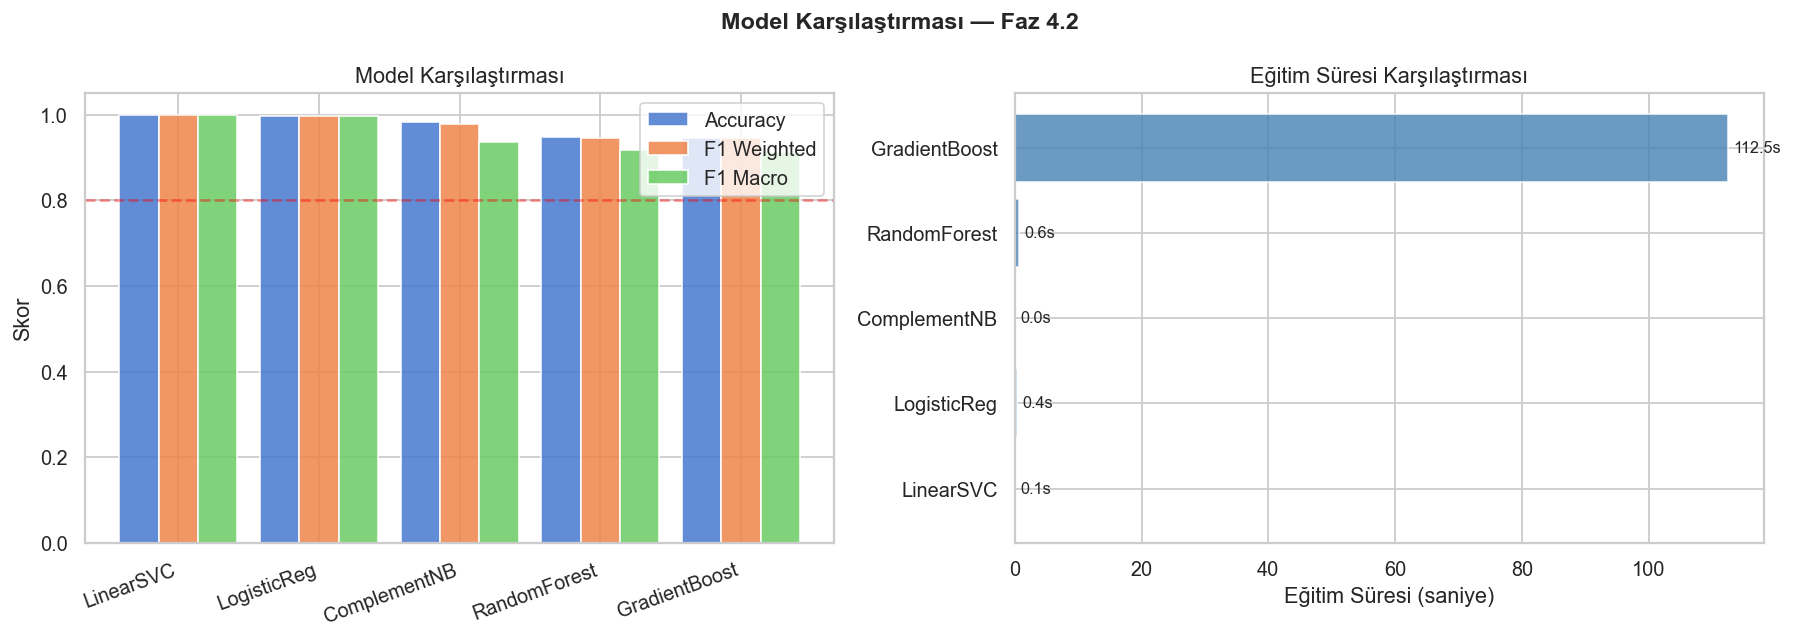

In [8]:
# Metrik karşılaştırma bar chart
metrics_df = pd.DataFrame([
    {'model': name, 'accuracy': m['accuracy'],
     'f1_weighted': m['f1_weighted'], 'f1_macro': m['f1_macro']}
    for name, m in results.items()
]).sort_values('f1_weighted', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
x = np.arange(len(metrics_df))
w = 0.28
ax.bar(x - w, metrics_df['accuracy'],    width=w, label='Accuracy',    alpha=0.85)
ax.bar(x,     metrics_df['f1_weighted'], width=w, label='F1 Weighted', alpha=0.85)
ax.bar(x + w, metrics_df['f1_macro'],   width=w, label='F1 Macro',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['model'], rotation=20, ha='right')
ax.set_ylabel('Skor')
ax.set_title('Model Karşılaştırması')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4)

# Eğitim süresi
ax = axes[1]
times = [results[m]['train_time'] for m in metrics_df['model']]
ax.barh(metrics_df['model'], times, color='steelblue', alpha=0.8)
ax.bar_label(ax.containers[0], fmt='%.1fs', padding=3, fontsize=9)
ax.set_xlabel('Eğitim Süresi (saniye)')
ax.set_title('Eğitim Süresi Karşılaştırması')

plt.suptitle('Model Karşılaştırması — Faz 4.2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/model_comparison.png', bbox_inches='tight')
plt.show()

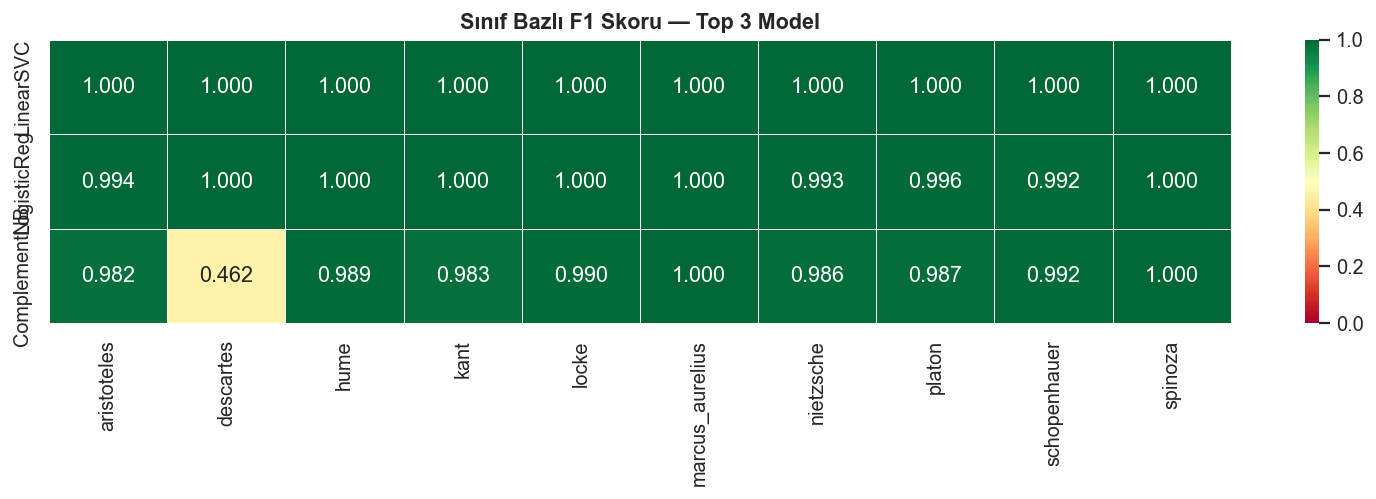

In [9]:
# Sınıf bazlı F1 ısı haritası — ilk 3 model
from sklearn.metrics import f1_score

top3 = list(metrics_df['model'].head(3))
phil_labels = [id2label[i] for i in sorted(id2label)]
f1_matrix = []

for name in top3:
    y_p = results[name]['y_pred']
    f1s = f1_score(y_val, y_p, average=None, labels=sorted(id2label), zero_division=0)
    f1_matrix.append(f1s)

f1_arr = np.array(f1_matrix)
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(f1_arr, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            xticklabels=phil_labels, yticklabels=top3,
            vmin=0, vmax=1, linewidths=0.3)
ax.set_title('Sınıf Bazlı F1 Skoru — Top 3 Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/model_class_f1.png', bbox_inches='tight')
plt.show()

## 7. Test Seti Değerlendirmesi (Final)

In [10]:
print(f'=== TEST SETİ DEĞERLENDİRMESİ — {best_name} ===')
best_clf = trained_models[best_name]

# ComplementNB için scaler gerekir
if best_name == 'ComplementNB':
    from sklearn.preprocessing import MaxAbsScaler
    scaler = MaxAbsScaler()
    scaler.fit(X_train_tfidf)
    X_test_input = scaler.transform(X_test_tfidf)
else:
    X_test_input = X_test_tfidf

y_test_pred = best_clf.predict(X_test_input)
test_metrics = evaluate_classification(y_test, y_test_pred, id2label)

print(f'Test Accuracy : {test_metrics["accuracy"]:.4f}')
print(f'Test F1 (W)   : {test_metrics["f1_weighted"]:.4f}')
print(f'Test F1 (M)   : {test_metrics["f1_macro"]:.4f}')
print()
print(test_metrics['report'])

2026-02-25 15:30:39.093 | INFO     | src.models.evaluate:evaluate_classification:17 - Accuracy: 0.9968 | F1: 0.9968


=== TEST SETİ DEĞERLENDİRMESİ — LinearSVC ===
Test Accuracy : 0.9968
Test F1 (W)   : 0.9968
Test F1 (M)   : 0.9928

                 precision    recall  f1-score   support

    aristoteles       1.00      0.99      0.99        83
      descartes       1.00      0.90      0.95        10
           hume       1.00      1.00      1.00        88
           kant       1.00      1.00      1.00        87
          locke       1.00      1.00      1.00        53
marcus_aurelius       1.00      1.00      1.00        23
      nietzsche       0.97      1.00      0.99        74
         platon       1.00      1.00      1.00       111
   schopenhauer       1.00      1.00      1.00        62
        spinoza       1.00      1.00      1.00        30

       accuracy                           1.00       621
      macro avg       1.00      0.99      0.99       621
   weighted avg       1.00      1.00      1.00       621



## 8. En İyi Modeli Kaydet

In [11]:
import os
os.makedirs('../models', exist_ok=True)

# Tam pipeline (tfidf + clf)
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                               sublinear_tf=True, stop_words='english')),
    ('clf',   MODELS[best_name]),
])
# Tüm train+val ile yeniden eğit
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
best_pipeline.fit(X_trainval, y_trainval)

model_path = f'../models/best_model_{best_name.lower()}.joblib'
joblib.dump(best_pipeline, model_path)

meta = {
    'model_name': best_name,
    'val_accuracy':   round(results[best_name]['accuracy'], 4),
    'val_f1_weighted': round(results[best_name]['f1_weighted'], 4),
    'test_accuracy':  round(test_metrics['accuracy'], 4),
    'test_f1_weighted': round(test_metrics['f1_weighted'], 4),
    'num_classes': len(id2label),
    'label_mapping': {str(k): v for k, v in id2label.items()},
    'train_samples': len(X_trainval),
    'test_samples':  len(X_test),
}
with open(f'../models/best_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Model kaydedildi: {model_path}')
print(f'Meta kaydedildi: models/best_model_meta.json')

Model kaydedildi: ../models/best_model_linearsvc.joblib
Meta kaydedildi: models/best_model_meta.json


In [12]:
print('=' * 60)
print('     FAZ 4.1 / 4.2 OZET RAPORU')
print('=' * 60)

for name, m in sorted(results.items(), key=lambda x: -x[1]['f1_weighted']):
    star = ' <-- EN IYI' if name == best_name else ''
    print(f'  {name:<20} Acc={m["accuracy"]:.4f}  F1W={m["f1_weighted"]:.4f}{star}')

print()
print(f'  Best model     : {best_name}')
print(f'  Test Accuracy  : {test_metrics["accuracy"]:.4f}')
print(f'  Test F1 (W)    : {test_metrics["f1_weighted"]:.4f}')
print(f'  Test F1 (M)    : {test_metrics["f1_macro"]:.4f}')
print()
print('  Sonraki adimlar:')
print('  Faz 4.3 — Hiperparametre Optimizasyonu (Optuna/GridSearch)')
print('  Faz 4.4 — BERT Fine-tuning (train.py transformer)')
print('=' * 60)

     FAZ 4.1 / 4.2 OZET RAPORU
  LinearSVC            Acc=1.0000  F1W=1.0000 <-- EN IYI
  LogisticReg          Acc=0.9968  F1W=0.9968
  ComplementNB         Acc=0.9823  F1W=0.9793
  RandomForest         Acc=0.9469  F1W=0.9450
  GradientBoost        Acc=0.9452  F1W=0.9448

  Best model     : LinearSVC
  Test Accuracy  : 0.9968
  Test F1 (W)    : 0.9968
  Test F1 (M)    : 0.9928

  Sonraki adimlar:
  Faz 4.3 — Hiperparametre Optimizasyonu (Optuna/GridSearch)
  Faz 4.4 — BERT Fine-tuning (train.py transformer)
